# 🏡 House Price Prediction using Machine Learning

## 📂 Import Libraries

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 📂 Load Data

In [2]:
dataset = pd.read_csv("house_price_data.csv")

In [3]:
dataset.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
dataset.shape

(21613, 21)

## 📚 Statistics Method

In [5]:
print("Dataset Info:")
dataset.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float

In [6]:
print("Missing Values:")
dataset.isnull().sum()

Missing Values:


id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [7]:
print("Statistical Summary:")
dataset.describe()

Statistical Summary:


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## 👉 Data Cleaning

In [8]:
dataset = dataset.dropna()

## 📈 EDA (Exploratory Data Analysis)

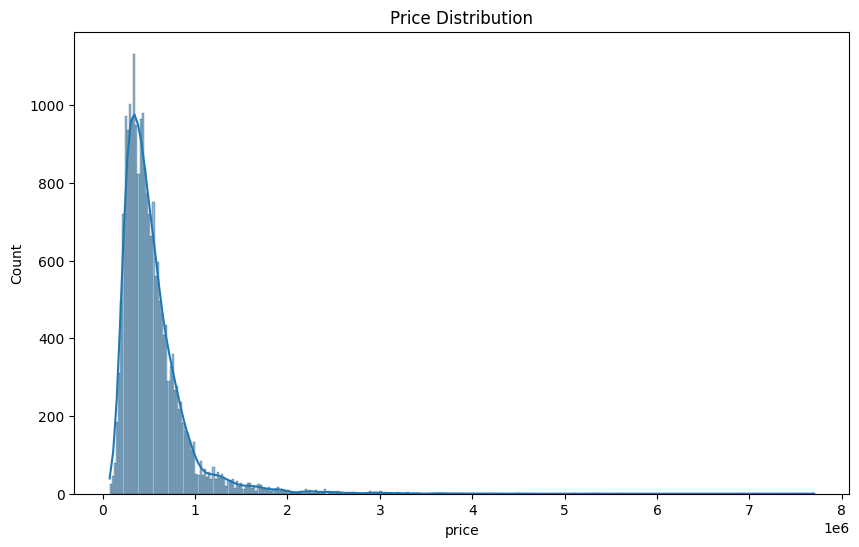

In [9]:
plt.figure(figsize = (10,6))
sns.histplot(dataset["price"], kde = True)
plt.title("Price Distribution")
plt.show()

C:\Users\baps\AppData\Local\Temp\ipykernel_7912\4243394340.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["price"])


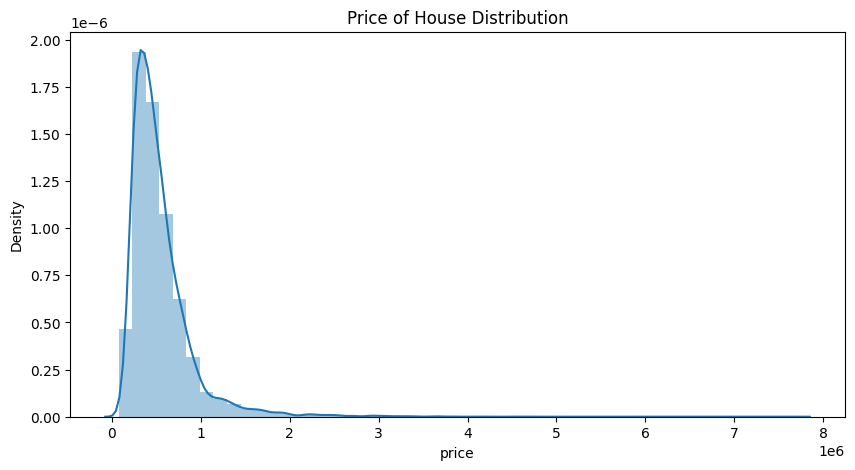

In [10]:
plt.figure(figsize = (10,5))
sns.distplot(dataset["price"])
plt.title("Price of House Distribution")
plt.show()

<Figure size 1000x500 with 0 Axes>

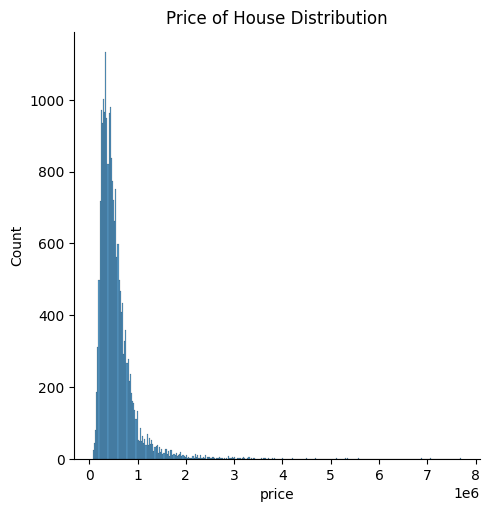

In [11]:
plt.figure(figsize = (10,5))
sns.displot(dataset["price"])
plt.title("Price of House Distribution")
plt.show()

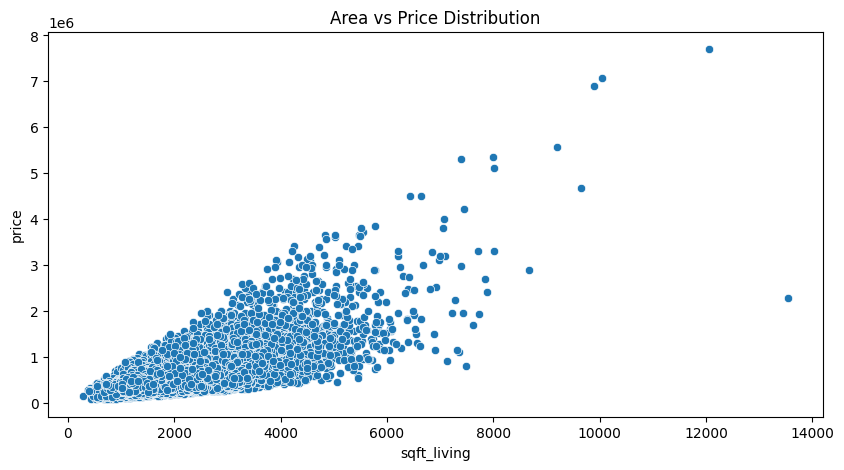

In [12]:
plt.figure(figsize = (10,5))
sns.scatterplot(x = dataset["sqft_living"], y = dataset["price"])
plt.title("Area vs Price Distribution")
plt.show()

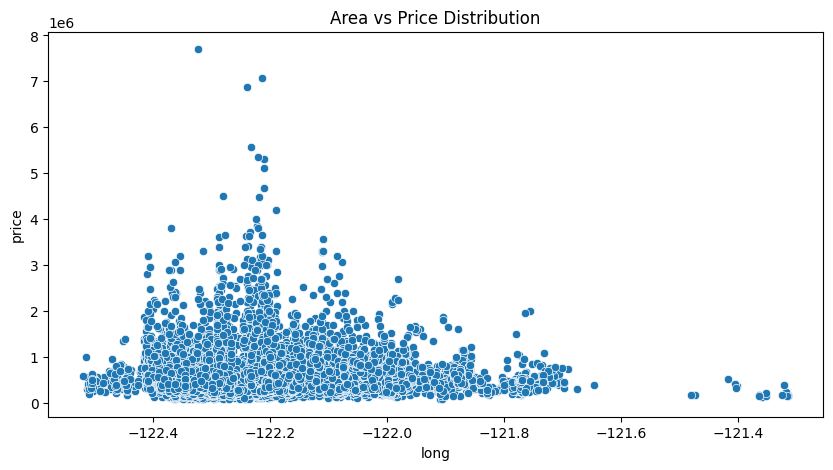

In [13]:
plt.figure(figsize = (10,5))
sns.scatterplot(x = dataset["long"], y = dataset["price"])
plt.title("Area vs Price Distribution")
plt.show()

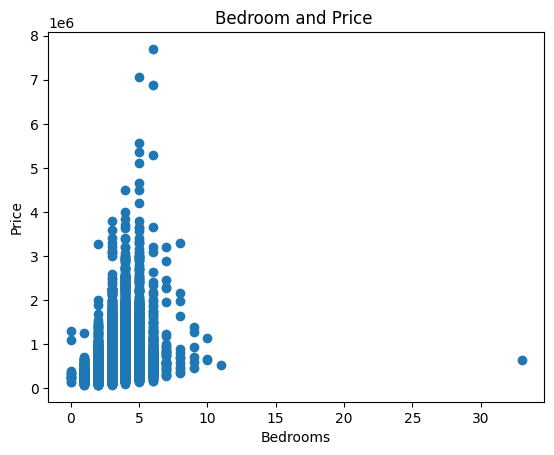

In [14]:
plt.scatter(dataset.bedrooms, dataset.price)
plt.title("Bedroom and Price ")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

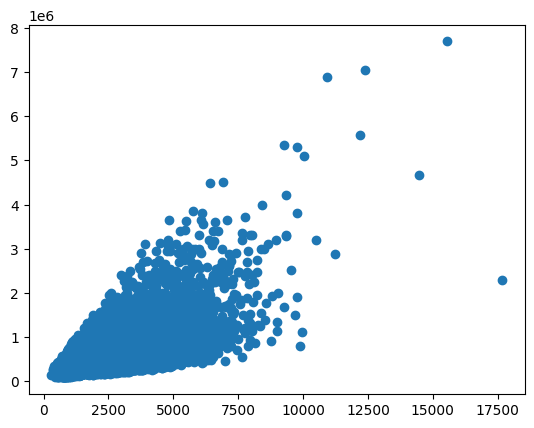

In [15]:
plt.scatter((dataset['sqft_living'] + dataset['sqft_basement']), dataset['price'])
plt.show()

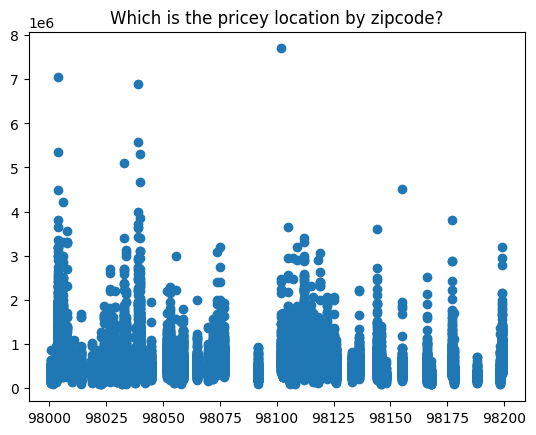

In [16]:
plt.scatter(dataset['zipcode'], dataset['price'])
plt.title("Which is the pricey location by zipcode?")
plt.show()

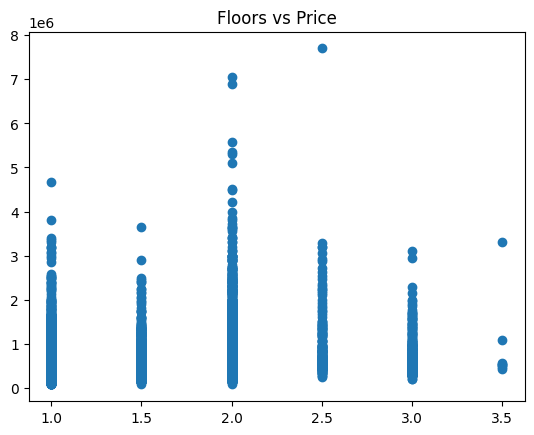

In [17]:
plt.scatter(dataset['floors'], dataset['price'])
plt.title("Floors vs Price")
plt.show()

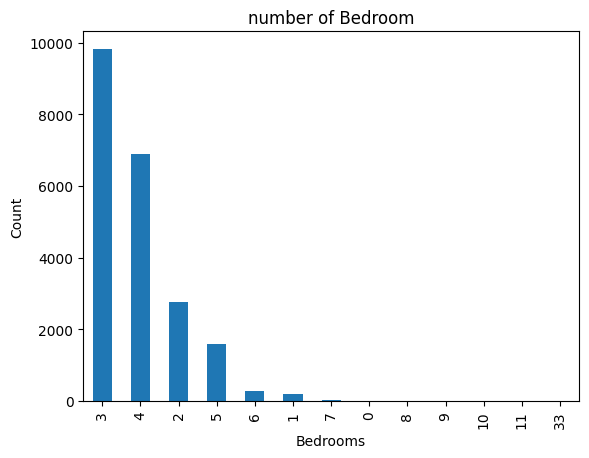

In [18]:
dataset['bedrooms'].value_counts().plot(kind = 'bar')
plt.title('number of Bedroom')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
sns.despine
plt.show()

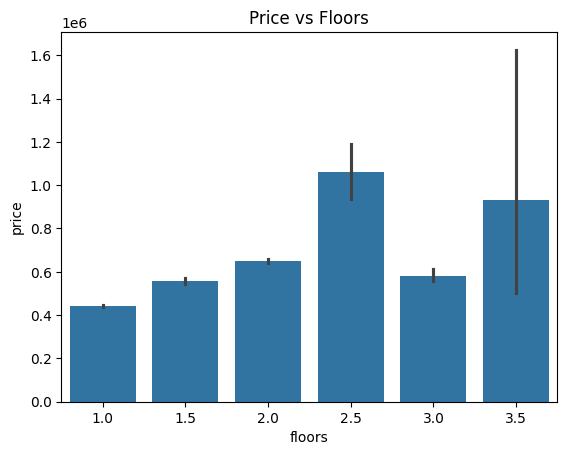

In [19]:
sns.barplot(x = "floors", y = "price", data = dataset)
plt.title("Price vs Floors")
plt.show()

In [20]:
# sns.pairplot(dataset, hue = "price")
# plt.title("Pair Plot")
# plt.show()

## 📊 Data Preprocessing

In [21]:
dataset = pd.get_dummies(dataset, drop_first = True)

## 🎯 Train-Test Split

In [22]:
x = dataset.drop("price", axis = 1)

In [23]:
y = dataset["price"]

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [25]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((17290, 390), (4323, 390), (17290,), (4323,))

## 🧠 Apply Multiple Models

## (1) Linear Regression

In [26]:
lr = LinearRegression()

In [27]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred_lr = lr.predict(x_test)

In [29]:
print("Linear Regression r2_score:", r2_score(y_test, y_pred_lr)*100)

Linear Regression r2_score: 69.64688106920171


In [30]:
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr)*100)

Linear Regression MAE: 12923388.85135134


In [31]:
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr))*100)

Linear Regression RMSE: 21421215.480685122


## (2) Decision Tree

In [32]:
dt = DecisionTreeRegressor(
    max_depth = 16, 
    min_samples_split = 10, 
    min_samples_leaf = 5
) 

In [33]:
dt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,16
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [34]:
y_pred_dt = dt.predict(x_test)

In [35]:
print("Decision Tree r2_score:", r2_score(y_test, y_pred_dt)*100)

Decision Tree r2_score: 77.32263194331841


In [36]:
print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_dt)*100)

Decision Tree MAE: 9480630.98209653


In [37]:
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)*100))

Decision Tree RMSE: 1851564.1888543274


## (3) Random Forest

In [38]:
rf = RandomForestRegressor(n_estimators = 200)

In [39]:
rf.fit(x_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
y_pred_rf = rf.predict(x_test)

In [41]:
print("Random Forest r2_score:", r2_score(y_test, y_pred_rf)*100)

Random Forest r2_score: 86.00161707779081


In [42]:
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf)*100)

Random Forest MAE: 7233807.55748323


In [43]:
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)*100))

Random Forest RMSE: 1454726.6090548122


## ⚙️ Model Comparison

In [44]:
models = ['LR', 'DT', 'RF']
mae = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf)
]

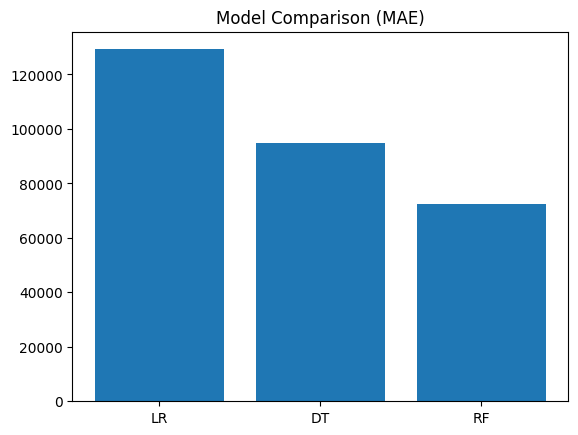

In [45]:
plt.bar(models, mae)
plt.title("Model Comparison (MAE)")
plt.show()

In [46]:
models_r2 = ['LR', 'DT', 'RF']
r2 = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

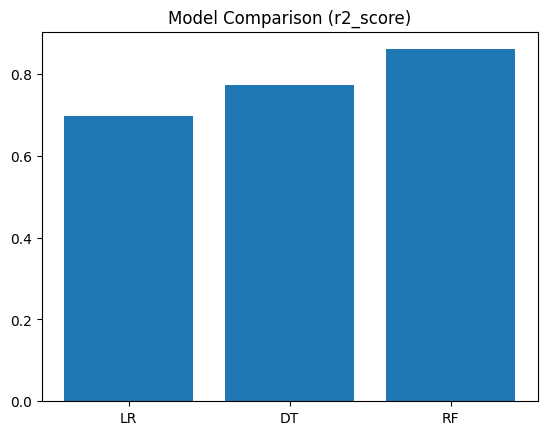

In [47]:
plt.bar(models_r2, r2)
plt.title("Model Comparison (r2_score)")
plt.show()

## 🌟 Best Model

In [48]:
print("Linear Regression r2_score:", r2_score(y_test, y_pred_lr)*100)
print("Decision Tree r2_score:", r2_score(y_test, y_pred_dt)*100)
print("Random Forest r2_score:", r2_score(y_test, y_pred_rf)*100)

Linear Regression r2_score: 69.64688106920171
Decision Tree r2_score: 77.32263194331841
Random Forest r2_score: 86.00161707779081


In [49]:
print(f"The Best Model of score is {r2_score(y_test, y_pred_rf)*100} in Random Forest.")

The Best Model of score is 86.00161707779081 in Random Forest.


## 📌 Final Prediction

In [50]:
# Example new data (same format as x)
new_data = x.iloc[0:1]

prediction = rf.predict(new_data)
print("Predicted Price:", prediction)

Predicted Price: [226368.365]


## 🧩 Check the Overfitting

In [51]:
print("Testing Score:", rf.score(x_test, y_test)*100)

Testing Score: 86.00161707779081


In [52]:
print("Training Score:", rf.score(x_train, y_train)*100)

Training Score: 98.34288454668831


## ⚠️ Cross Validation Score

In [53]:
cv_score = cross_val_score(RandomForestRegressor(), x, y, cv = 5)

In [54]:
print("Cross Validation Scores:", cv_score)

Cross Validation Scores: [0.87379616 0.87484565 0.87371782 0.87036517 0.8722043 ]


In [55]:
print("Average CV Score:", cv_score.mean())

Average CV Score: 0.8729858210254573


## 👉 Check the Best Parameter using GridSearchCV and RandomizedSearchCV

In [56]:
from sklearn.model_selection import GridSearchCV

In [57]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}

In [58]:
grid = GridSearchCV(RandomForestRegressor(), param_grid = params, cv = 5)

In [ ]:
grid.fit(x_train, y_train)

In [ ]:
best_model = grid.best_estimator_

In [ ]:
print("Best Parameters:", grid.best_params_)

In [ ]:
print("Best CV Score:", grid.best_score_)

In [ ]:
y_predict = best_model.predict(x_test)

In [ ]:
print("Sample Prediction:", y_predict[:5])

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
randomized = RandomizedSearchCV(RandomForestRegressor(), param_distributions = params, n_iter = 20)

In [ ]:
randomized.fit(x_train, y_train)

In [ ]:
best_model_randomized = randomized.best_estimator_

In [ ]:
print("Best Parameters:", randomized.best_params_)

In [ ]:
print("Best CV Score:", randomized.best_score_)

In [ ]:
y_predict_randomized = best_model_randomized.predict(x_test)

In [ ]:
print("Sample Prediction:", y_predict_randomized[:5])